In [1]:
import pandas as pd
df = pd.read_csv('demand_clean.csv')
df.head()

,mineral,technology,2024,2030,2035,2040
0,Copper,Solar PV,1657.2,2373.7,2242.6,2230.2
1,Copper,Wind,534.2,809.8,769.8,622.8
2,Copper,Other low emissions power generation,75.7,118.8,81.5,85.5
3,Copper,Electric vehicles,496.7,1597.1,2465.5,2995.5
4,Copper,Grid battery storage,76.3,215.3,294.9,449.0


In [2]:
df_long = df.melt(
id_vars=['mineral', 'technology'],
var_name='year',
value_name='demand'
)

In [3]:
df_long['year'] = df_long['year'].astype(int)    #converted them to integers
df_long = df_long.sort_values(['mineral','technology','year'])

In [4]:
print(f"Rows before: {len(df)}")
print(f"Rows after: {len(df_long)}")
df_long.head(8)

Rows before: 23
Rows after: 92


,mineral,technology,year,demand
8,Cobalt,Electric vehicles,2024,66.5
31,Cobalt,Electric vehicles,2030,143.1
54,Cobalt,Electric vehicles,2035,142.7
77,Cobalt,Electric vehicles,2040,135.8
9,Cobalt,Grid battery storage,2024,4.1
32,Cobalt,Grid battery storage,2030,5.1
55,Cobalt,Grid battery storage,2035,3.7
78,Cobalt,Grid battery storage,2040,0.0


In [5]:
df_long.to_csv('demand_long.csv', index=False)
print("Saved")

Saved


step_01_regression

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

df = pd.read_csv('demand_long.csv')
df.head()

,mineral,technology,year,demand
0,Cobalt,Electric vehicles,2024,66.5
1,Cobalt,Electric vehicles,2030,143.1
2,Cobalt,Electric vehicles,2035,142.7
3,Cobalt,Electric vehicles,2040,135.8
4,Cobalt,Grid battery storage,2024,4.1


In [7]:
copper = df[df['mineral'] == 'Copper']

X = copper[['year']]   # feature, double brackets — DataFrame
y = copper['demand']   # this is target, single brackets — Series

print(X.shape, y.shape)

(28, 1) (28,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Trained")

Trained


In [10]:
y_pred = model.predict(X_test)

print(f"R²:  {r2_score(y_test, y_pred):.3f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.1f}")

R²:  -1.988
MSE: 1972019.9


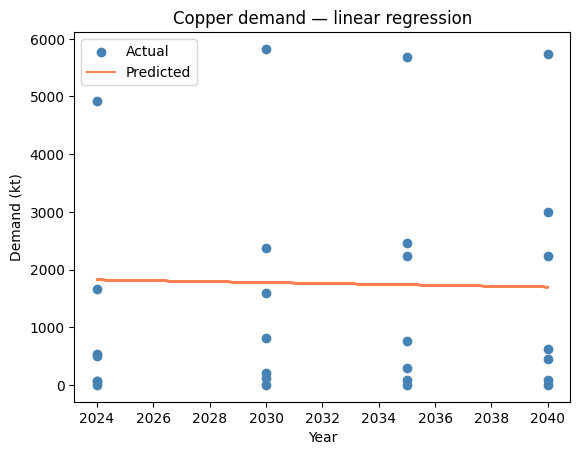

In [11]:
plt.scatter(X, y, label='Actual', color='steelblue')
plt.plot(X, model.predict(X), label='Predicted', color='coral')
plt.xlabel('Year')
plt.ylabel('Demand (kt)')
plt.title('Copper demand — linear regression')
plt.legend()
plt.show()

## Insight, why the model fails with year alone

My first regression model uses only `year` as a feature to predict
copper demand. The result is a flat orange line sitting around 1700kt
regardless of the year, which is clearly wrong for most data points.

The reason is that copper demand varies enormously depending on which
technology is using it. In 2024 alone:

- Electricity networks: ~4929 kt
- Solar PV: ~1657 kt
- Electric vehicles: ~496 kt
- Hydrogen: 0 kt

The model has no idea which technology each row belongs to it only
sees the year. So it draws the one line that is least wrong on average
across all technologies, which turns out to be nearly flat.

**The fix:** year alone is not enough. I need to encode `technology`
as a feature and run multiple regression so the model can learn a
separate demand pattern per technology. That is Step 3 and Step 4.

## Evaluation, Step 1 results

- **R²: -1.988**  worse than predicting the average. The model learned
  almost nothing useful from year alone.
- **MSE: 1,972,019** roughly 1,404 kt average error per prediction.

A negative R² confirms the chart: one line across all technologies
is meaningless. The model needs `technology` as a feature to
differentiate between electricity networks (4929 kt) and
hydrogen (0 kt) in the same year.

Expected R² after adding technology in Step 4: above 0.8.

## Step 2 Train/test split

Split: 80% train (22 rows), 20% test (6 rows).

The model only learns from the training set. R² and MSE are measured
on the test set rows the model has never seen. This gives an honest
measure of real world performance, not a score inflated by memorising
the training data.

random_state=42 fixes the random shuffle so results are reproducible.

In [3]:
import pandas as pd

df = pd.read_csv('demand_long.csv')

df_encoded = pd.get_dummies(df, columns=['mineral', 'technology'])

print(df_encoded.shape)
df_encoded.head()

(92, 15)


,year,demand,mineral_Cobalt,mineral_Copper,mineral_Lithium,mineral_Magnet rare earth elements,mineral_Nickel,technology_Electric vehicles,technology_Electricity networks,technology_Grid battery storage,technology_Hydrogen technologies,technology_Low emissions power generation,technology_Other low emissions power generation,technology_Solar PV,technology_Wind
0,2024,66.5,True,False,False,False,False,True,False,False,False,False,False,False,False
1,2030,143.1,True,False,False,False,False,True,False,False,False,False,False,False,False
2,2035,142.7,True,False,False,False,False,True,False,False,False,False,False,False,False
3,2040,135.8,True,False,False,False,False,True,False,False,False,False,False,False,False
4,2024,4.1,True,False,False,False,False,False,False,True,False,False,False,False,False


In [4]:
print(df_encoded.columns.tolist())

['year', 'demand', 'mineral_Cobalt', 'mineral_Copper', 'mineral_Lithium', 'mineral_Magnet rare earth elements', 'mineral_Nickel', 'technology_Electric vehicles', 'technology_Electricity networks', 'technology_Grid battery storage', 'technology_Hydrogen technologies', 'technology_Low emissions power generation', 'technology_Other low emissions power generation', 'technology_Solar PV', 'technology_Wind']


In [5]:
df_encoded.to_csv('demand_encoded.csv', index=False)
print("Saved.")

Saved.


In [7]:
#values are showing True and False instead of 1 and 0, so we convert them
df_encoded = pd.get_dummies(df, columns=['mineral', 'technology'], dtype=int)
print(df_encoded.shape)
df_encoded.head()

(92, 15)


,year,demand,mineral_Cobalt,mineral_Copper,mineral_Lithium,mineral_Magnet rare earth elements,mineral_Nickel,technology_Electric vehicles,technology_Electricity networks,technology_Grid battery storage,technology_Hydrogen technologies,technology_Low emissions power generation,technology_Other low emissions power generation,technology_Solar PV,technology_Wind
0,2024,66.5,1,0,0,0,0,1,0,0,0,0,0,0,0
1,2030,143.1,1,0,0,0,0,1,0,0,0,0,0,0,0
2,2035,142.7,1,0,0,0,0,1,0,0,0,0,0,0,0
3,2040,135.8,1,0,0,0,0,1,0,0,0,0,0,0,0
4,2024,4.1,1,0,0,0,0,0,0,1,0,0,0,0,0


In [8]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv('demand_encoded.csv')

X = df.drop(columns=['demand'])   # everything except demand
y = df['demand']                  # target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X.shape)

(92, 14)


In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"R²:  {r2_score(y_test, y_pred):.3f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.1f}")

R²:  0.807
MSE: 442027.2


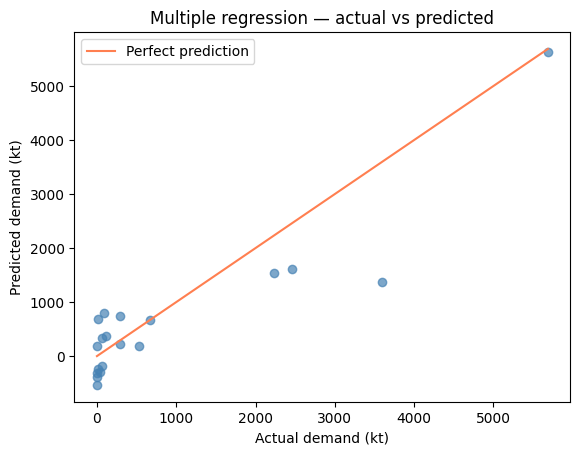

In [10]:
plt.scatter(y_test, y_pred, color='steelblue', alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='coral', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual demand (kt)')
plt.ylabel('Predicted demand (kt)')
plt.title('Multiple regression — actual vs predicted')
plt.legend()
plt.show()

## Insight Step 4 results

| | Step 1 (year only) | Step 4 (all features) |
|---|---|---|
| R² | -1.988 | 0.807 |
| MSE | 1,972,019 | 442,027 |

Adding mineral and technology as one-hot encoded features drove R²
from -1.99 to 0.81, an 80% drop in error. The model now explains
80% of the variation in mineral demand.

features matter more than the model itself. A simple
linear regression with the right features massively outperforms the
same model with the wrong ones

In [12]:
df = pd.read_csv('demand_encoded.csv')

X = df.drop(columns=['demand'])
y = df['demand']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print(f"R²:  {r2_score(y_test, y_pred):.3f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.1f}")

R²:  0.756
MSE: 559220.4


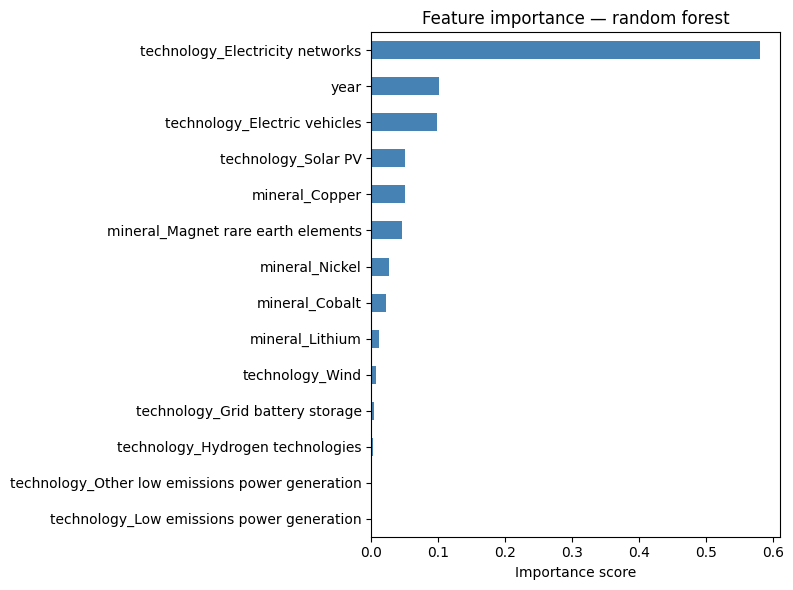

In [16]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', color='steelblue', figsize=(8,6))
plt.title('Feature importance — random forest')
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()

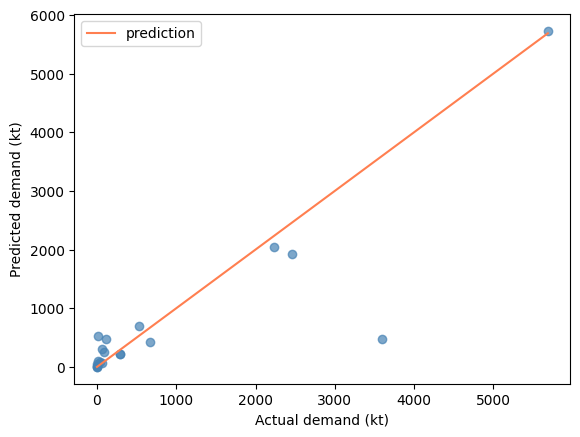

In [18]:
plt.scatter(y_test, y_pred, color='steelblue', alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='coral', linewidth=1.5, label='prediction')
plt.xlabel('Actual demand (kt)')
plt.ylabel('Predicted demand (kt)')
plt.legend()
plt.show()

## Insight Step 5 results

| | Step 1 | Step 4 (linear) | Step 5 (random forest) |
|---|---|---|---|
| R² | -1.988 | 0.807 | 0.756 |
| MSE | 1,972,019 | 442,027 | 559,220 |

Random forest performed worse than linear regression on this dataset.
Reason: only 92 rows is too small for a tree-based model to generalise
well. Linear regression wins here because the demand patterns are
largely linear and the dataset is small